# Constante de gravitación *G* — **medición 30** (Cavendish casero)

Análisis **no paramétrico** de la balanza de torsión amortiguada (imanes de Foucault) con bola de
plomo. Esta medición tiene, en orden: **T3 sin masa**, **T4 con masa** (bola a `d` cm CM–CM) y
**T5 sin masa** (retorno).

**Modelo.** En equilibrio el torque elástico iguala al gravitatorio:
$$\kappa\,\Delta\theta = G\,\tau_1(\Delta\theta)\;\Rightarrow\; G=\frac{\kappa\,\Delta\theta}{\tau_1},
\qquad \kappa=I\,\omega_0^2,\quad \omega_0^2=\omega_d^2+\beta^2 .$$

Se calculan **todos los análisis posibles y se comparan**:
- **tramos:** solo el primer par (T3→T4, *placement*) vs. los tres tramos (T3→T4→T5, con corrección de deriva);
- **equilibrio:** por **media directa** de la señal vs. por **picos** (extremos / midline);
- **κ:** período (mín/máx/cruces) vs. ajuste del ring-down.

Las incertezas se tratan con cuidado y **sin sobreestimar** (ver §6).

## ⚙️ Configuración (constantes, ventanas e incertezas)

In [21]:
%matplotlib inline
import glob, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.5,
})
C_SM, C_CM, C_R = "#2563eb", "#dc2626", "#16a34a"   # sin masa / con masa / retorno

# ---------- rutas ----------
BASE  = Path(r"C:\Users\olive\Documents\labo-4-2026\CAVENDISH\Datos")
OUT   = Path(r"C:\Users\olive\Documents\labo-4-2026\CAVENDISH\informe")
FIGS  = OUT / "figuras"; FIGS.mkdir(exist_ok=True)
CACHE = OUT / "_cache"; CACHE.mkdir(exist_ok=True)
USAR_CACHE = True
NOMBRE  = "medicion30"
G_CODATA = 6.674e-11

# ---------- calibración óptica ----------
FACTOR_ESPEJO = 2.0          # el haz gira 2θ cuando el espejo gira θ

# ---------- geometría (todas las longitudes con incerteza SIG_LONG = 1 mm) ----------
LX_P, LY_P, LZ_P = 14.04e-2, 3.48e-2, 7e-2   # prisma colgante [m]
R_BRAZO = 37e-2                               # brazo eje->CM del prisma [m]
MASA_PRISMA = 3.75                            # kg por prisma (se CANCELA en G)
DENS_P = MASA_PRISMA / (LX_P * LY_P * LZ_P)
R_BOLA = 5.3e-2                               # radio bola (no entra en G: esfera = puntual)
M_BOLA = 4.6                                  # kg (masa MEDIDA de la bola)
N_GL = 12; INCLUIR_BRAZO_LEJANO = False

SIG_LONG = 1e-3       # incerteza de TODA longitud medida: 1 mm  (r, d, L, dims del prisma)
SIG_MB   = 0.05       # incerteza de la masa de la bola [kg]

# ---------- detección no paramétrica ----------
SEP_MIN_S = 60.0; VENTANA_EXTREMO_S = 5.0

T_MAX = 60*180


# ---------- tramos de la medición 30 (editar acá) ----------
D_CM_CM = 7.5e-2      # distancia CM-CM bola-prisma en equilibrio [m]
T0_PLOT = 0        # recorte de los gráficos (no se muestra lo previo a T3)
SIN_MASA   = dict(win=(0, T_MAX),   pico="max", desde=1, hasta=9)   # T3 sin masa
CON_MASA   = dict(win=(100000, 12803),  pico="max", desde=2, hasta=11)  # T4 con masa
RETORNO    = dict(win=(100000, 16441), pico="max", desde=3, hasta=9)   # T5 sin masa (para 3 tramos)
RING_DOWN  = (5980, 8919)                                             # ventana semilla del ajuste de κ
print("Config OK — medición 30, d =", D_CM_CM*100, "cm")

Config OK — medición 30, d = 7.5 cm


In [22]:
# =================== Lectura de datos ===================
def parse_meta(path):
    d = {}
    for ln in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        ln = ln.strip()
        if "\t" in ln and not ln.startswith("#"):
            k, v = ln.split("\t", 1); d[k] = v
    return d

def load_medicion(nombre):
    """Concatena los chunks en orden temporal -> (t, x_mm, y_mm). Cose reinicios de cámara; cachea.
    Devuelve también meta (mm_por_px, width_px, distancia a la pantalla...)."""
    carpeta = BASE / nombre
    meta = parse_meta(glob.glob(str(carpeta / "*_meta.txt"))[0])
    L_mm  = float(meta["distancia_a_la_pantalla (cm)"]) * 10.0
    mm_px = float(meta["mm_por_px"]); w_px = float(meta["width_px"])
    events = sorted(float(v) for k, v in meta.items() if re.match(r"masa_\d+_s$", k))
    cache = CACHE / f"{nombre}.npy"
    if USAR_CACHE and cache.exists():
        d = np.load(cache); t, x, y = d[0], d[1], d[2]
    else:
        archivos = sorted(glob.glob(str(carpeta / "*_[0-9][0-9][0-9][0-9].txt")),
                          key=lambda f: int(re.search(r"_(\d+)\.txt$", f).group(1)))
        partes = []
        for f in archivos:
            try: a = pd.read_csv(f, sep="\t", header=None, dtype=float).values
            except Exception:
                try: a = np.atleast_2d(np.loadtxt(f))
                except Exception: continue
            if a.size and a.shape[1] >= 3: partes.append(np.atleast_2d(a[:, :3]))
        datos = np.concatenate(partes, axis=0)
        t, x, y = datos[:, 0].copy(), datos[:, 1].copy(), datos[:, 2].copy()
        dd = np.diff(t); dt_med = np.median(dd[dd > 0])
        for j in np.flatnonzero(dd < 0): t[j + 1:] += (t[j] - t[j + 1] + dt_med)
        np.save(cache, np.vstack([t, x, y]))
    return dict(t=t, x_mm=x, y_mm=y, L_mm=L_mm, mm_px=mm_px, w_px=w_px, events=events, meta=meta)

def a_rad(v_mm, L_mm):
    """Posición del haz [mm] -> ángulo del péndulo [rad] (palanca óptica)."""
    return np.arctan(v_mm / L_mm) / FACTOR_ESPEJO
print("I/O listo.")

I/O listo.


In [23]:
# =================== No paramétrico (cruces, extremos, períodos, equilibrios) ===================
def cruces(t, x, nivel, sep_min_s=SEP_MIN_S):
    arr = x > nivel; i = np.flatnonzero(arr[1:] != arr[:-1])
    if len(i) == 0: return np.array([]), np.array([], dtype=int)
    grupos = np.split(np.arange(len(i)), np.flatnonzero(np.diff(t[i]) > sep_min_s) + 1)
    tc, dc = [], []
    for g in grupos:
        if arr[i[g[0]]] == arr[i[g[-1]] + 1]: continue
        tc.append(float(t[i[g]].mean())); dc.append(+1 if arr[i[g[-1]] + 1] else -1)
    return np.array(tc), np.array(dc, dtype=int)

def extremos(ts, xs, t_cr, d_cr, v=VENTANA_EXTREMO_S):
    te, xe, tipo = [], [], []
    for i in range(len(t_cr) - 1):
        a, b = t_cr[i], t_cr[i + 1]; es_max = (d_cr[i] == +1); w = (ts >= a) & (ts <= b)
        if w.sum() < 10: continue
        tw, xw = ts[w], xs[w]; tg = np.arange(a + v, b - v + 1e-9, v)
        if len(tg) < 1:
            j = int(np.argmax(xw) if es_max else np.argmin(xw)); te.append(float(tw[j])); xe.append(float(xw[j]))
        else:
            md_ = np.array([np.median(xw[np.abs(tw - g) <= v]) for g in tg])
            j = int(np.argmax(md_) if es_max else np.argmin(md_)); te.append(float(tg[j])); xe.append(float(md_[j]))
        tipo.append(+1 if es_max else -1)
    return np.array(te), np.array(xe), np.array(tipo, dtype=int)

def extremos_tramo(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    return extremos(ts, xs, tc, dc)

def picos(te, xe, tipo, kind):
    m = tipo == (+1 if kind == "max" else -1); return te[m], xe[m]

def intervalo_por_picos(te, tipo, kind, desde, hasta):
    tk = picos(te, te, tipo, kind)[0]
    if len(tk) < hasta: return (tk[0] if len(tk) else np.nan), (tk[-1] if len(tk) else np.nan), len(tk)
    return float(tk[desde - 1]), float(tk[hasta - 1]), len(tk)

def periodo_tramo(t, th, win, modo="min"):
    m = (t >= win[0]) & (t <= win[1]); ts, xs = t[m], th[m]
    tc, dc = cruces(ts, xs, float(np.median(xs)))
    if modo == "cruces":
        seps = np.concatenate([np.diff(tc[dc > 0]), np.diff(tc[dc < 0])])
    else:
        te, xe, tipo = extremos(ts, xs, tc, dc)
        sd = lambda k: np.diff(picos(te, te, tipo, k)[0])
        seps = np.concatenate([sd("min"), sd("max")]) if modo == "ambos" else sd(modo)
    if len(seps) == 0: return np.nan, np.nan, 0
    return float(np.median(seps)), (float(np.std(seps)) if len(seps) > 1 else np.nan), len(seps)

def midlines(te, xe, t_lo, t_hi):
    m = (te >= t_lo - 1e-6) & (te <= t_hi + 1e-6); tu, xu = te[m], xe[m]
    if len(xu) < 2: return np.array([]), np.array([])
    return 0.5 * (tu[1:] + tu[:-1]), 0.5 * (xu[1:] + xu[:-1])

def analizar_tramo(t, th, sel):
    """Equilibrio del tramo por DOS métodos + incerteza de la variación INTERNA del valor medio.
      - eq_media : media directa de la señal entre los picos (robusto; usa todas las muestras).
      - eq_picos : midline (extremos) detrendeado.
      - sig_eq   : SEM de la media-por-ciclo (incerteza por la variación del valor medio en el tramo).
    """
    te, xe, tipo = extremos_tramo(t, th, sel["win"])
    t_lo, t_hi, ndisp = intervalo_por_picos(te, tipo, sel["pico"], sel["desde"], sel["hasta"])
    aviso = f" (hay {ndisp} {sel['pico']}, se pidió {sel['hasta']})" if ndisp < sel["hasta"] else ""
    msk = (t >= t_lo) & (t <= t_hi)
    eq_media = float(np.mean(th[msk]))
    # midline por extremos (detrendeado)
    tm, mids = midlines(te, xe, t_lo, t_hi)
    if len(mids) >= 3:
        p = np.polyfit(tm, mids, 1); eq_picos = float(np.polyval(p, tm.mean()))
    else:
        eq_picos = float(mids.mean()) if len(mids) else eq_media
    # variación interna: media de la señal en cada ciclo (entre picos consecutivos) -> SEM
    tk = picos(te, te, tipo, sel["pico"])[0]; tk = tk[(tk >= t_lo - 1e-6) & (tk <= t_hi + 1e-6)]
    mc = [float(np.mean(th[(t >= a) & (t <= b)])) for a, b in zip(tk[:-1], tk[1:]) if ((t >= a) & (t <= b)).sum() > 5]
    mc = np.array(mc)
    var_eq = float(mc.std(ddof=1)) if len(mc) > 1 else np.nan
    sig_eq = float(var_eq / np.sqrt(len(mc))) if len(mc) > 1 else np.nan
    me = (te >= t_lo - 1e-6) & (te <= t_hi + 1e-6)
    return dict(eq_media=eq_media, eq_picos=eq_picos, sig_eq=sig_eq, var_eq=var_eq, n_ciclos=len(mc),
                t_lo=t_lo, t_hi=t_hi, tc=0.5*(t_lo+t_hi), te_u=te[me], xe_u=xe[me], tm=tm, mids=mids, aviso=aviso)
print("No paramétrico listo.")

No paramétrico listo.


In [24]:
# =================== Ajuste amortiguado, inercia, torque y propagación ===================
def modelo_amortiguado(t, eq, A, beta, wd, phi):
    return eq + A * np.exp(-beta * t) * np.cos(wd * t + phi)

def ajustar_amortiguado(t, th, win):
    m = (t >= win[0]) & (t <= win[1]); tt = t[m] - t[m][0]; xx = th[m]
    eq0 = np.mean(xx); A0 = (xx.max() - xx.min()) / 2
    s = np.sign(xx - eq0); cr = tt[np.flatnonzero((s[:-1] < 0) & (s[1:] >= 0))]
    wd0 = 2*np.pi / (np.median(np.diff(cr)) if len(cr) > 1 else tt[-1]/4)
    h = len(xx)//2; Ai = (xx[:h].max()-xx[:h].min())/2; Af = (xx[h:].max()-xx[h:].min())/2
    beta0 = max(1e-5, np.log(max(Ai, 1e-9)/max(Af, 1e-9))/(tt[-1]/2))
    p0 = [eq0, A0, beta0, wd0, 0.0]
    bnd = ([eq0-1, 0, 0, wd0*0.5, -2*np.pi], [eq0+1, 5*A0, 1e-1, wd0*1.5, 2*np.pi])
    popt, _ = curve_fit(modelo_amortiguado, tt, xx, p0=p0, bounds=bnd, maxfev=200000)
    eq, A, beta, wd, phi = popt; resid = xx - modelo_amortiguado(tt, *popt)
    return dict(eq=eq, A=A, beta=beta, wd=wd, w0=np.hypot(wd, beta), rms=float(np.sqrt(np.mean(resid**2))),
                win=win, t0=t[m][0], tt=tt, xx=xx, fit=modelo_amortiguado(tt, *popt), resid=resid)

def mejor_ventana_ajuste(t, th, win0, n_pasos=10, frac_fin=0.92):
    a0, b0 = win0; b = a0 + frac_fin*(b0-a0); paso = (b-a0)/(n_pasos+4); cand = []
    for k in range(n_pasos):
        a = a0 + k*paso
        if b-a < 4*paso: break
        try: f = ajustar_amortiguado(t, th, (a, b)); cand.append((f["rms"]/f["A"], f))
        except Exception: pass
    cand.sort(key=lambda z: z[0]); return cand[0][1]

def inercia(r=R_BRAZO, lx=LX_P, ly=LY_P, lz=LZ_P, dens=DENS_P):
    return 2*(dens*lx*ly*lz/12*(lx**2+ly**2) + dens*lx*ly*lz*r**2)

def torque_z(phi, R_arm, lp, dens, fuente, M, n_gl=N_GL):
    nodes, w = np.polynomial.legendre.leggauss(n_gl)
    hx, hy, hz = lp[0]/2, lp[1]/2, lp[2]/2
    U, V, Wz = np.meshgrid(hx*nodes, hy*nodes, hz*nodes, indexing="ij")
    WT = (w*hx)[:, None, None]*(w*hy)[None, :, None]*(w*hz)[None, None, :]
    c, s = np.cos(phi), np.sin(phi)
    xp = (U+R_arm)*c - V*s; yp = (U+R_arm)*s + V*c; zp = Wz
    xc, yc, zc = fuente; dx, dy, dz = xc-xp, yc-yp, zc-zp
    r = np.sqrt(dx*dx + dy*dy + dz*dz); f = M/r**3
    return float(np.sum((xp*(f*dy) - yp*(f*dx)) * dens * WT))

def tau_por_G(dtheta, d, r=R_BRAZO, M=M_BOLA, lp=(LX_P, LY_P, LZ_P), dens=DENS_P):
    tau = torque_z(abs(dtheta), r, lp, dens, (r, d, 0.0), M)
    if INCLUIR_BRAZO_LEJANO: tau += torque_z(abs(dtheta)+np.pi, r, lp, dens, (r, d, 0.0), M)
    return tau

def G_de(kappa, dtheta, d): return kappa*abs(dtheta)/tau_por_G(dtheta, d)

def G_full(omega0, dtheta, cal, d, r, M, lx, ly, lz):
    """G en función de todas las variables independientes (para propagar). `cal`=factor de escala
    de la calibración px->grados (nominal 1). La densidad del colgado se cancela."""
    dens = MASA_PRISMA/(lx*ly*lz)
    I = 2*(dens*lx*ly*lz/12*(lx**2+ly**2) + dens*lx*ly*lz*r**2)
    kappa = I*omega0**2
    dth = abs(dtheta)*cal
    tau = torque_z(dth, r, (lx, ly, lz), dens, (r, d, 0.0), M)
    if INCLUIR_BRAZO_LEJANO: tau += torque_z(dth+np.pi, r, (lx, ly, lz), dens, (r, d, 0.0), M)
    return kappa*dth/tau

def presupuesto_G(inputs, sigmas):
    """Propagación por Jacobiano numérico. Devuelve (G, sigma_G, dict de contribuciones a la varianza)."""
    G0 = G_full(**inputs); var = 0.0; contrib = {}
    for k, s in sigmas.items():
        if not s: contrib[k] = 0.0; continue
        h = abs(inputs[k])*1e-5 if inputs[k] != 0 else 1e-6
        up = dict(inputs); up[k] += h; dn = dict(inputs); dn[k] -= h
        ci = ((G_full(**up) - G_full(**dn))/(2*h) * s)**2; contrib[k] = ci; var += ci
    return G0, np.sqrt(var), contrib
print("Ajuste, torque y propagación listos.")

Ajuste, torque y propagación listos.


# 0) Simulacion

In [25]:
from poincare import *
from symbolite import real
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from itertools import zip_longest

plt.style.use("seaborn-v0_8")

fontsize = 15
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

class Duffing(System):
    t = Independent()
    x = initial(default=1)
    v = x.derive(initial=0)
    
    x_0 = assign(default=0)
    Dx = assign(default=(x-x_0))
    alpha = assign(default =1e-4/1.04) #Cte. elástica
    beta = assign(default = 0) # Termino cubico
    delta = assign(default=2.98e-03/1.04) # Amortiguamiento 

    eq = v.derive() << -alpha*Dx -beta *Dx**3 -delta*v 

# Patadas paramétricas (el equilibrio cambia azarosamente)
rng = np.random.default_rng(seed=42)
probabilidad_patada_eq = 1/(10*60) # 1/s
probabilidad_patada_v = 1/(10*60) # 1/s
std_patada_eq = 0.05
std_patada_v = 0.01
std_ruido = 0

sim = Simulator(Duffing)

# Dividir por tiempos
tiempos = np.linspace(0,T_MAX, int(5e4))
dt = tiempos[1]-tiempos[0]
limite_eq = probabilidad_patada_eq * dt
limite_v = probabilidad_patada_eq * dt
rand_eq = rng.random(len(tiempos))
rand_v = rng.random(len(tiempos))
mask_eq = rand_eq < limite_eq
mask_v = rand_v < limite_v
combined_mask = (mask_eq | mask_v)
combined_mask[0] = False 
split_indices = np.where(combined_mask)[0]
labels = []
for idx in split_indices:
    if mask_eq[idx]:
        labels.append("eq")
    else:
        labels.append("v")
subtiempos = np.split(tiempos, split_indices)

# Simular por partes
eq = {Duffing.x_0: 0}
utlimos_valores = {Duffing.x: 1, Duffing.v: 0}
vals = utlimos_valores | eq
resultados = []
equilibrios = []
for tiempo, tipo in zip_longest(subtiempos, labels):
    resultado = sim.solve(save_at=(tiempo), values = vals)
    resultados.append(resultado)
    patada_eq = rng.normal(0, std_patada_eq) if tipo == "eq" else 0
    patada_v = rng.normal(0, std_patada_v) if tipo == "v" else 0
    eq = {Duffing.x_0: eq[Duffing.x_0] + patada_eq} 
    equilibrios.append(eq[Duffing.x_0] + patada_eq)
    utlimos_valores = {Duffing.x: resultado["x"].values[-1], Duffing.v: resultado["v"].values[-1]+patada_v}
    vals = utlimos_valores | eq
resultado_final = xr.concat(resultados, dim = "time")

## 1) Señal y tramos

medicion30: 3.00 h | eventos = [5970, 5980, 8919, 12803] s
calibración: mm_por_px = 0.3014, ancho = 1920 px, L pantalla = 121 cm | I_colgado = 1.0398 kg·m²


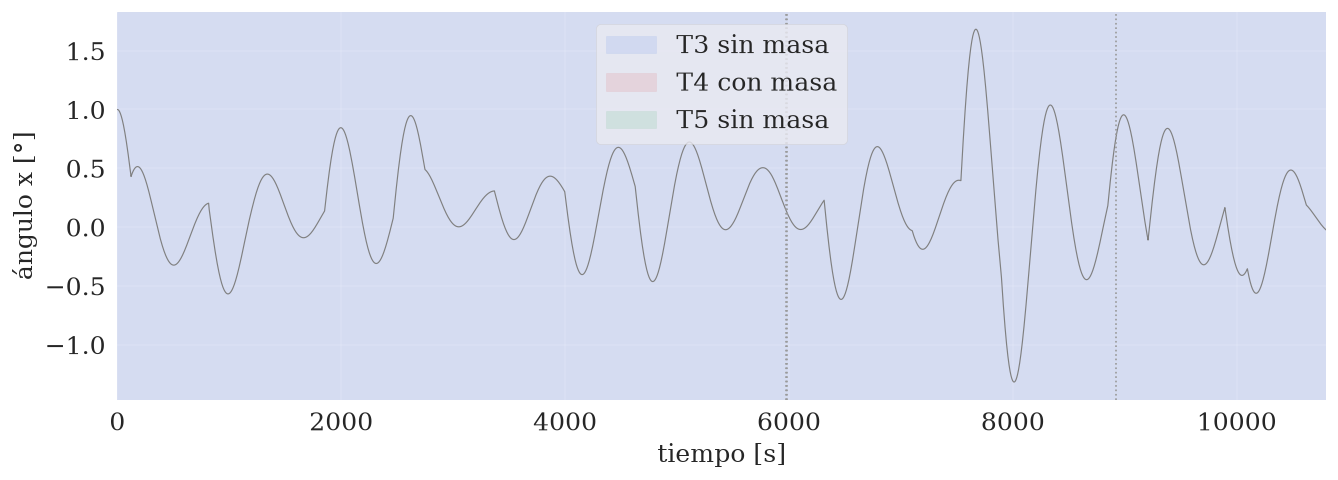

In [ ]:
m = load_medicion(NOMBRE); t = m["t"]; ev = m["events"]
th = resultado_final["x"] * np.pi/180; Dth = np.zeros_like(th)
t = tiempos
print(f"{NOMBRE}: {t[-1]/3600:.2f} h | eventos = {[round(e) for e in ev]} s")
print(f"calibración: mm_por_px = {m['mm_px']:.4f}, ancho = {m['w_px']:.0f} px, "
      f"L pantalla = {m['L_mm']/10:.0f} cm | I_colgado = {inercia():.4f} kg·m²")
mv = t >= T0_PLOT
fig, ax = plt.subplots(figsize=(13, 4.2)); ax.plot(t[mv], np.degrees(th[mv]), lw=0.7, color="0.5")
for sel, c, lab in [(SIN_MASA, C_SM, "T3 sin masa"), (CON_MASA, C_CM, "T4 con masa"), (RETORNO, C_R, "T5 sin masa")]:
    ax.axvspan(sel["win"][0], sel["win"][1], alpha=0.10, color=c, label=lab)
for e in ev:
    if e >= T0_PLOT: ax.axvline(e, color="0.6", ls=":", lw=1)
ax.set_xlim(T0_PLOT, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="best")
# fig.savefig(FIGS / "m30_senal.png"); plt.show()

## 3) Equilibrios y Δθ — todos los análisis

Para cada tramo se mide el equilibrio por **media directa** y por **picos**. La incerteza de cada
equilibrio sale de la **variación del valor medio dentro del tramo** (SEM de la media por ciclo). Con eso:
- **2 tramos** (primer par, T3→T4): $\Delta\theta=\mathrm{eq}(T4)-\mathrm{eq}(T3)$ (*placement*).
- **3 tramos** (T3→T4→T5): $\Delta\theta=\mathrm{eq}(T4)-$ baseline interpolada (corrige deriva lineal).

  T3 sin masa: media=+nan°  picos=+nan°  σ(variación interna)=±nan°  (0 ciclos) (hay 0 max, se pidió 9)
  T4 con masa: media=+nan°  picos=+nan°  σ(variación interna)=±nan°  (0 ciclos) (hay 0 max, se pidió 11)
  T5 retorno: media=+nan°  picos=+nan°  σ(variación interna)=±nan°  (0 ciclos) (hay 0 max, se pidió 9)


,analisis,dtheta_deg,sig_dtheta_deg
0,2 tramos · media,NaN,NaN
1,2 tramos · picos,NaN,NaN
2,3 tramos · media,NaN,NaN
3,3 tramos · picos,NaN,NaN


retorno eq(T5)-eq(T3) = +nan°  -> el equilibrio NO vuelve (hay deriva)


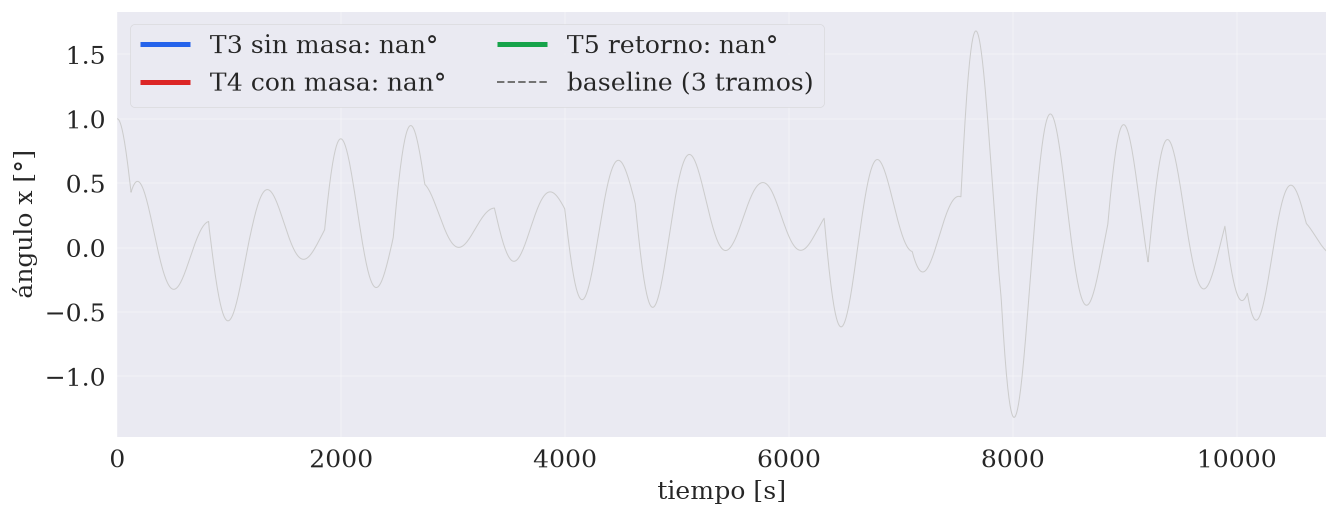

In [ ]:
A = analizar_tramo(t, th, SIN_MASA)   # T3
B = analizar_tramo(t, th, CON_MASA)   # T4
C = analizar_tramo(t, th, RETORNO)    # T5
for nom, R in [("T3 sin masa", A), ("T4 con masa", B), ("T5 retorno", C)]:
    print(f"  {nom}: media={np.degrees(R['eq_media']):+.4f}°  picos={np.degrees(R['eq_picos']):+.4f}°  "
          f"σ(variación interna)=±{np.degrees(R['sig_eq']):.4f}°  ({R['n_ciclos']} ciclos){R['aviso']}")

def dtheta_2t(est):  # placement
    v = B[est] - A[est]; s = np.hypot(A["sig_eq"], B["sig_eq"]); return v, s
def dtheta_3t(est):  # con retorno (deriva lineal)
    base = np.interp(B["tc"], [A["tc"], C["tc"]], [A[est], C[est]])
    v = B[est] - base; s = np.hypot(B["sig_eq"], 0.5*np.hypot(A["sig_eq"], C["sig_eq"])); return v, s

analisis = {
    "2 tramos · media":   dtheta_2t("eq_media"),
    "2 tramos · picos":   dtheta_2t("eq_picos"),
    "3 tramos · media":   dtheta_3t("eq_media"),
    "3 tramos · picos":   dtheta_3t("eq_picos"),
}
df_dt = pd.DataFrame([dict(analisis=k, dtheta_deg=np.degrees(v), sig_dtheta_deg=np.degrees(s))
                      for k, (v, s) in analisis.items()])
display(df_dt)
ret = C["eq_media"] - A["eq_media"]
print(f"retorno eq(T5)-eq(T3) = {np.degrees(ret):+.4f}°  -> el equilibrio "
      f"{'vuelve' if abs(ret) < abs(B['eq_media']-A['eq_media']) else 'NO vuelve (hay deriva)'}")

mv = t >= T0_PLOT
fig, ax = plt.subplots(figsize=(13, 4.6)); ax.plot(t[mv], np.degrees(th[mv]), lw=0.6, color="0.8")
for R, c, lab in [(A, C_SM, "T3 sin masa"), (B, C_CM, "T4 con masa"), (C, C_R, "T5 retorno")]:
    ax.hlines(np.degrees(R["eq_media"]), R["t_lo"], R["t_hi"], color=c, lw=3, label=f"{lab}: {np.degrees(R['eq_media']):.3f}°")
ax.plot([A["tc"], C["tc"]], np.degrees([A["eq_media"], C["eq_media"]]), "--", color="0.45", lw=1.2, label="baseline (3 tramos)")
ax.set_xlim(T0_PLOT, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("ángulo x [°]"); ax.legend(loc="best", ncol=2)
# fig.savefig(FIGS / "m30_corrimiento.png"); plt.show()

## 4) Evolución del valor medio (curva medida + extremos considerados)

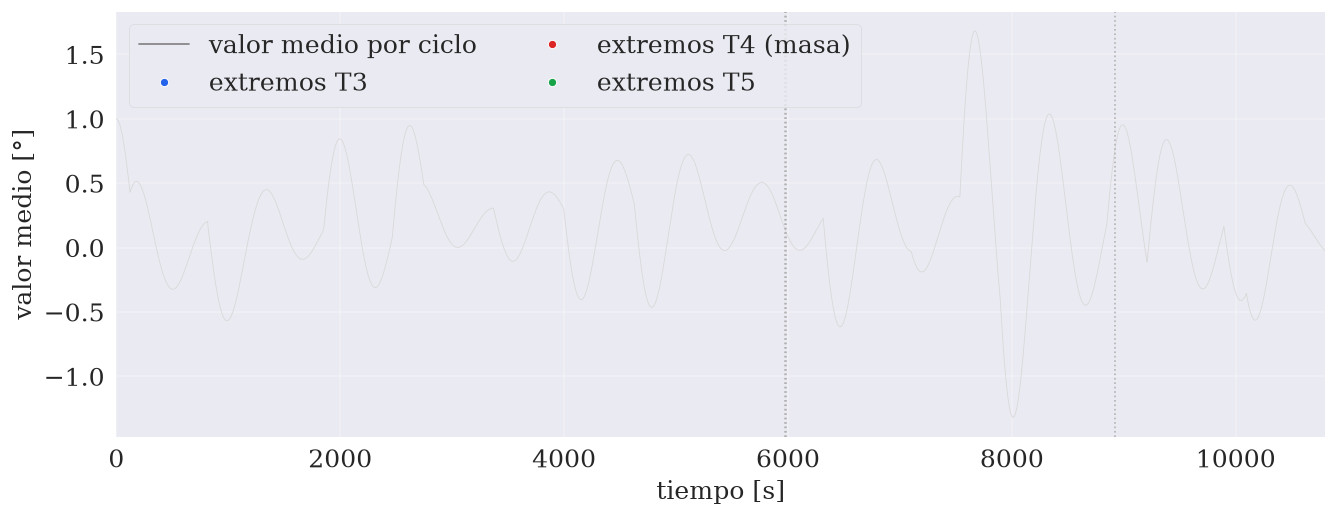

In [ ]:
te_all, xe_all, tipo_all = extremos_tramo(t, th, (T0_PLOT, t[-1]))
tm_all, mid_all = midlines(te_all, xe_all, T0_PLOT, t[-1])
mv = t >= T0_PLOT
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(t[mv], np.degrees(th[mv]), lw=0.5, color="0.85")
ax.plot(tm_all, np.degrees(mid_all), "-", lw=1.0, color="0.5", label="valor medio por ciclo")
for R, c, lab in [(A, C_SM, "T3"), (B, C_CM, "T4 (masa)"), (C, C_R, "T5")]:
    ax.plot(R["te_u"], np.degrees(R["xe_u"]), "o", ms=5, color=c, mec="white", mew=0.6, label=f"extremos {lab}")
    ax.hlines(np.degrees(R["eq_media"]), R["t_lo"], R["t_hi"], color=c, lw=3)
for e in ev:
    if e >= T0_PLOT: ax.axvline(e, color="0.7", ls=":", lw=1)
ax.set_xlim(T0_PLOT, t[-1]); ax.set_xlabel("tiempo [s]"); ax.set_ylabel("valor medio [°]"); ax.legend(loc="best", ncol=2)
# fig.savefig(FIGS / "m30_evolucion.png"); plt.show()